пропуски = ['GiftAvgCard36' 'DemAge' 'DemMedIncome']
не числовые признаки = ['StatusCat96NK' 'DemGender' 'DemHomeOwner']
StatusCat96NK    6
DemGender        3
DemHomeOwner     2
dtype: int64


<Axes: xlabel='TargetD', ylabel='Density'>

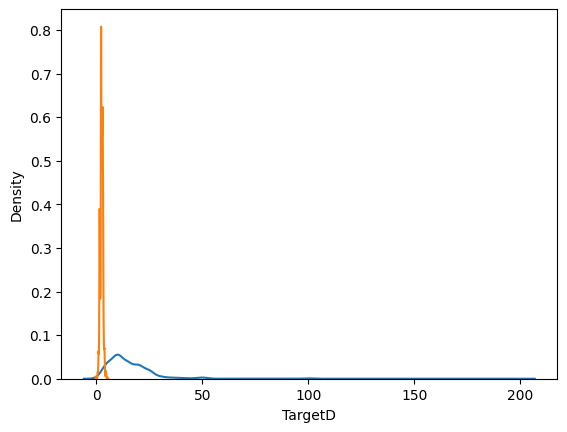

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#В файле «donations.csv» находится выборка с информацией об участниках программы
# пожертвования денег на нужды ветеранских организаций. Каждая запись – один человек из
# списка рассылки. У него есть социо-демографические признаки (пол, возраст, медианная
# оценка дохода в районе его проживания, является ли он домовладельцем и т.д. и т.д.),
# поведенческие признаки (агрегированные характеристики его ранних пожертвований типа
# GiftCount36 – число пожертвований за три года, GiftAmntLast – сумма последнего
# пожертвования, PromCntCard12 – число контактов с ним за год в рамках рекламной компании
# и т.д.). Также есть два отклика: флаг TargetB (пожертвовал или нет) и TargetD – сумма
# пожертвования (пропуск, если не жертвовал, иначе сумма в долларах). В рамках первой части
# задания нужно построить регрессионные модели (только по людям, кто пожертвовал деньги),
# объясняющие и прогнозирующие сумму пожертвования TargetD.

df_donate = pd.read_csv('donations.csv')

# В задании два отклика , нужно модель по одному TargetD тогда уберем воторой отклик
# перед этим, также проверим распределение отклика
# sns.kdeplot(df_donate['TargetD'])
# такой хвост можно было проверить и skew()
#df_donate['TargetD'].skew()

df_ = df_donate.copy(deep=True)
df_.drop(columns=['TargetB'], inplace=True)
df_ = df_[df_['TargetD'].notna()]
print(f'пропуски = {df_.columns[df_.isna().any()].values}')
print(f'не числовые признаки = {df_.select_dtypes(exclude=["number"]).columns.values}')
print(df_[df_.select_dtypes(exclude=["number"]).columns.values].nunique())
# теперь заполним пропуски , перед этим заенкодим объектные переменные 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le_StatusCat96NK = LabelEncoder().fit_transform(df_['StatusCat96NK'])
ohe_DemGender_DemHomeOwner = OneHotEncoder().fit(df_[['DemGender','DemHomeOwner']])
ohe_values = ohe_DemGender_DemHomeOwner.transform(df_[['DemGender','DemHomeOwner']]).toarray()
df_['StatusCat96NK'] = le_StatusCat96NK
df_[ohe_DemGender_DemHomeOwner.get_feature_names_out(['DemGender','DemHomeOwner'])] = ohe_values
df_.drop(columns=['DemGender','DemHomeOwner'], inplace=True, axis=1)

#Заполним пропуски импутером KNNImputer
from sklearn.impute import SimpleImputer, MissingIndicator
indicators = MissingIndicator().fit(df_)
indicators_values = indicators.transform(df_)
df_[df_.iloc[:,indicators.features_].columns.to_numpy() + '_missing'] = indicators_values
# print(df_)
df_sim = SimpleImputer(strategy='median').fit_transform(df_.to_numpy())
df_[df_.columns] = df_sim

# еще раз проверим распределение отклика
sns.kdeplot(df_['TargetD'])
y_gamma = df_['TargetD']
# тяжелый правый хвост , сделаем более симметричное распределение путем log
df_['TargetD'] = np.log(df_['TargetD']) 
sns.kdeplot(df_['TargetD'])

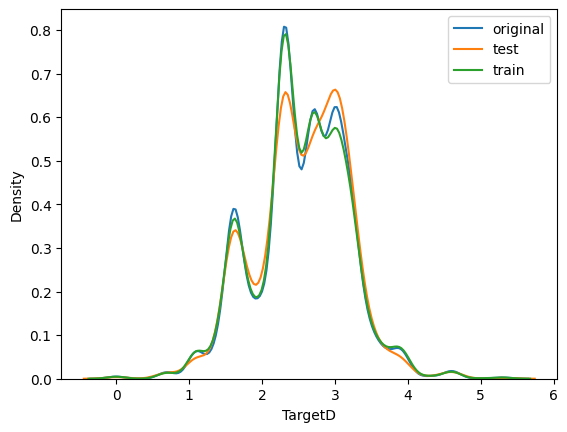

In [38]:
# Выберите и сохраните в качестве проверочной выборки (holdout) 30% исходной выборки со
# стратификацией по отклику. Обратите внимание, что отклик непрерывный и его нужно
# дискретизировать. Число интервалов и метод дискретизации выберите самостоятельно.
# Постройте и визуализируйте гистограмму (или kde апроксимацию) для распределения отклика
# во всем исходном наборе, в проверочной и в тренировочной выборках. 
from sklearn.model_selection import train_test_split
# прежде чем разбить выборку на тренировочную и тестовую , сделаем дискретизацию отклика
y = df_['TargetD']
df_new = df_.drop(columns=['TargetD'], inplace=False)
X_columns = df_new.columns
X = df_new.to_numpy()
y_targetD_bins = pd.cut(df_['TargetD'], bins=5, labels=False)
# bin_lenght = (Xmax - Xmin) / bins
# после дискретизации отклика, будем его стратифицировать
#Стратификация понимается как разделение признаков и отклика на заданные две части, где первая часть тренировочная для модели _train, вторая проверочная _test
#при этом, эти части имеют приблизительно равное распределение отклика
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y_targetD_bins)

sns.kdeplot(y, label='original') # исходная
sns.kdeplot(y_test, label='test') # проверочная
sns.kdeplot(y_train, label='train') # тренировочная
plt.legend()

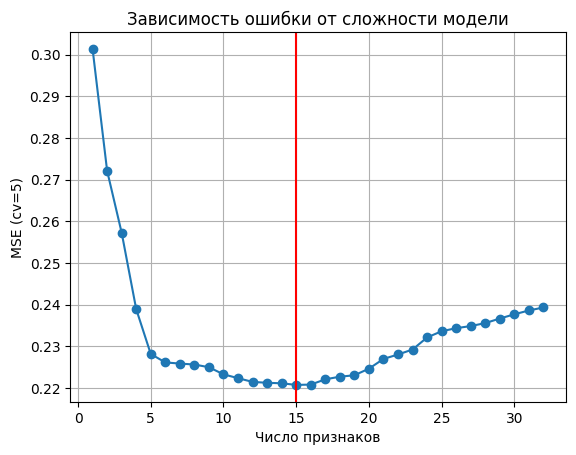

Количество признаков для наилучшей модели = 15


In [80]:
# Произведите отбор важных переменных с помощью линейного регрессионного метода из
# вашего варианта (LARS), перебрав все возможные сложности моделей в рамках вашего метода и
# выбрав лучшую по кросс-валидации c 5 блоками и MSE в качестве критерия. В пошаговых
# регрессионных методах для остановки и выбора следующего шага используйте R-квадрат, pvalue или AIC на ваше усмотрение. Постройте график зависимости CV-MSE от сложности (число
# переменных или число компонент в модели), график трассы стандартизованных
# коэффициентов от сложности. Вертикальной линией на этих графиках обозначьте лучшую по CV
# сложность модели.

#Lars или метод наименьшего угла, работает след. образом
#Стандартизирует признаки и отклик, StandardScaler'ом
#Вычисляем коррелции столбцов признаков с откликом (скалярное произведение), берем макс.
#Инициализируем веса (w_i..n = 0), n - количество предикторов
#Выбираем первую corr(x_i,y) и вторую corr(x_i+1,y), составляем уравнение и получаем вес для макс корр. признака с откликом w_i = (corr(x_i,y) - corr(x_i+1,y)) - a - a*corr(x_i, x_i+1) 
# корреляция с откликом потому что r_0 = y, но потом корреляция с r_i
#теперь пересчитываем остатки , с направлением d, если активные признаки попарно ортагональны т.е. (X^T*X) = I , then d= 0, тогда d =1, иначе d = 1/скалярное произв. активных признаков
#где a - параметр подбирающийся для равенства corr(x_i,y) == corr(x_i+1,y)
# посчитав, снова корректируем w_i , w_i = w_i + p, w_i+1 = p, а также w_i+2 где p = искомый параметр чтобы корреляция с остатками, была равная как у активных так и у неактивных признаков. 
#шаг сверху делается чтобы неактивный признак включить в активные, его корреляция была равна корреляциям активного
#затем снова пересчитываем остатки пока r_i != 0 , r_i = y - Xw ,как только остатки равны нулю, выявляются незначительные признаки (неактивные)
# и опять включаем след. неактивный признак, и пересчитываем чтобы корреляция его стала равной как у активных признаков
# останова - либо досчитываются все признаки, но у некоторых столбец остается нулевой по причине отсутствия корреляции
from sklearn.linear_model import Lars
from sklearn.pipeline import Pipeline # позволяет описать модель в виде объекта
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv # Эти три импорта позволяют методом Отбора выбрать наилучшие метапараметры, есть GridSearch, RandomizeSearch и HalvingSearch
from sklearn.model_selection import HalvingRandomSearchCV, HalvingGridSearchCV
from sklearn.model_selection import cross_val_score

scaler = StandardScaler().fit(X_train)
X_train_ = scaler.transform(X_train)
X_test_ = scaler.transform(X_test)

mse = []
for n in range(1,len(X_columns)+1):
    Lars_ = Lars(n_nonzero_coefs=n,fit_intercept=True)
    estimations = -cross_val_score(Lars_, X_train_, y_train,cv=5, scoring='neg_mean_squared_error') # возвращает оценку 
    mse.append(estimations.mean())

plt.plot(range(1, len(X_columns) + 1), mse, 'o-')
best_n = np.argmin(mse) + 1
plt.axvline(best_n, color='r', linestyle='solid')
plt.xlabel('Число признаков')
plt.ylabel('MSE (cv=5)')
plt.title('Зависимость ошибки от сложности модели')
plt.grid(True)
plt.show()
print(f'Количество признаков для наилучшей модели = {best_n}')

def smart_choosing_params(X_train,y_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_ = scaler.transform(X_train)
    X_test_ = scaler.transform(X_test)
    
    model = Pipeline([("lars", Lars())])
    distributions = {"lars__n_nonzero_coefs": np.arange(2,len(X_columns)+1),
                     "lars__fit_intercept": [True, False]} # Для Lars , какое количество активных признаков будет наилучшим варинатов для нашей модели, и lars__fit_intercept центрирование
    
    # HalvingRandomSearchCV или отбор, примечателен скоростью выбора метапараметров, и работает след образом
    # у нас есть 100 кандидатов(комбинаций метапараметров), и n=1000
    #мы задаем минимальное min_resource = 100, значит начнем обучение на 100 наблюдениях
    # из них мы выберем лучшую часть комбинаций как долю 1/factor, в нашем случае половину (= 2), остальных отбрасываем
    # далее увеличиваем количество ресурсов (="n_samples") в 2 раза и обучаемся на оставшихся параметрах, далее повторяем предыдущий шаг
    # Кандидаты отбираются случайным образом из пространства параметров, а количество отобранных кандидатов определяется формулой n_candidates.
    #HalvingGridSearchCV работает полным перепобором и пересчетом , самый медленный вариант
    #RandomizeSearchCV работает по приницу грида, только не перебирает все , а случайно выбирает меньшее число кобминаций и из них выбирает лучшие
    #cv -параметр указывает на количество разбиений для модели, когда мы выбираем наилучшие комбинации моделе запускается cv=5, и эти 5 моделей оцениваются по критерию, 
    # берется средняя оценка критерия MSE например, и т.д.
    # scores = 'neg_mean_squared_error' и есть критерий MSE = (1/n) sum((yᵢ - ŷᵢ)^2)
    HGSV = HalvingGridSearchCV(model, distributions, cv=5, resource= "n_samples",factor=2, scoring='neg_mean_squared_error')
    HGSV.fit(X_train, y_train)
    return HGSV,X_train_,X_test_
    # print(HRSV.best_params_)
# smart_choosing_params(X_train_, y_train, X_test_)

OOB-MSE= 0.24819036761077454
CV-MSE= 0.2207583151213252
MSE-Bootstrapping= 0.19744554413479967


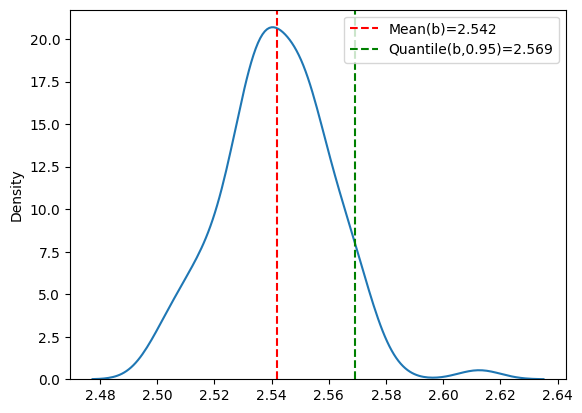

In [81]:
# Для лучшей выбранной сложности линейной модели с помощью бутстреппинга (100 бутстреп
# выборок размера 25% от исходной) постройте гистограммы (или kde аппроксимацию)
# распределения константы смещения в полученном регрессионном уравнении (константы b
# если регрессии y=ax+b) с указанием на графике среднего значения и 95% интервала.
# Аналогично оцените OOB ошибку MSE. Как она соотносится с лучшей кросс-валидационной
# ошибкой и ошибкой на проверочной части выборки?
from sklearn.ensemble import BaggingClassifier, BaggingRegressor # Для классификаций(пожертвовал да или нет) и для прогнозирования суммы(сколько)
#Бутстреппинг ,другими словами метод построения ансамбля моделей неазивисимых друг от друга, берутся в нашем примере 100 раз по 25% от выборки, таким образом что могут
# повторяться наблюдения
model_bc = BaggingRegressor(estimator=Lars(n_nonzero_coefs=best_n, fit_intercept=True),max_samples=0.25,n_estimators=100,oob_score=True).fit(X_train_, y_train)
#print(model_bc.estimators_)
#Для распределения свободного члена , выберем их из всех моделей
b = []
for lars_m in model_bc.estimators_:
    b.append(lars_m.intercept_)
sns.kdeplot(b)
plt.axvline(np.mean(b), c='r', linestyle='--', label=f'Mean(b)={np.mean(b):.3f}')
plt.axvline(np.quantile(b, 0.95), c='g', linestyle='--', label=f'Quantile(b,0.95)={np.quantile(b, 0.95):.3f}')
plt.legend()
# oob_prediction_ - каждое наблюдение , в те модели которое не попало на основе них предсказывается и усредняется, oob_score - уже оцененное с поомщью коэф.детерминации
oob_mse_log = np.sum((model_bc.oob_prediction_ - y_train)**2) * (1/len(y_train))

print('OOB-MSE=',oob_mse_log) # mse оценка oob - на данных не вошедших в обучение модели 
print('CV-MSE=',np.min(mse))
print('MSE-Bootstrapping=', np.sum((model_bc.predict(X_test_) - y_test)**2) * (1/len(y_test)))

{'GLM__alpha': np.float64(1.6326530612244898), 'polynom__degree': 1}


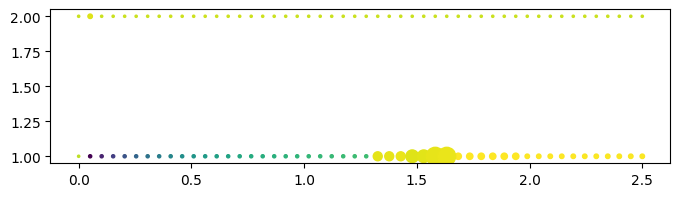

In [110]:
# Используйте отобранные переменные для построения нелинейной модели прогнозирования
# числового отклика с помощью метода из вашего варианта, при этом отбирая метапараметры
# также с помощью метода из вашего варианта. Замечания:
# -В PLS регрессиях для отбора переменных (после отбора числа компонент по кроссвалидации) используйте VIP статистику с любым порогом в диапазоне [0.5,1].
# -Обратите внимание, что категориальные переменные можно либо включить в модель
# целиком (со всеми уровнями), либо не включать.
# -Для однослойного MLP можно варьировать число нейронов и константу регуляризации,
# для Poisson Regression, Gamma Regression и полиномиальной гребневой регрессии -
# константу регуляризации и степень полинома (для Gamma и Poisson воспользуйтесь
# PolynomialFeatures).

#Для начала все таки выберем важные переменные методом Lars с наилучшей сложностью
# print(X_columns)
lars_var = Lars(n_nonzero_coefs=best_n, fit_intercept=True).fit(X_train_, y_train)
idx = np.nonzero(lars_var.coef_)
X_columns_after_lars = X_columns[idx] 
X_gamma = X[:, idx[0]]

# Gamma Regressor, когда предполагается что отклик ассиметричен
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import GammaRegressor
# gamma_model = sm.GLM(y_gamma, X_gamma, family=sm.families.Gamma(sm.families.links.Log()))
# gamma_results = gamma_model.fit()
# print(gamma_results.summary())
X_train_gamma, X_test_gamma, y_train_gamma, y_test_gamma = train_test_split(X_gamma,y_gamma, test_size = 0.3)

scaler_g = StandardScaler().fit(X_train_gamma)
X_train_g = scaler_g.transform(X_train_gamma)
X_test_g = scaler_g.transform(X_test_gamma)

gamma_model = Pipeline([("polynom", PolynomialFeatures()),
                        ("GLM", GammaRegressor(max_iter=1000))])
distributions_gamma = {"GLM__alpha": np.linspace(0,2.5,50),
                       "polynom__degree": [1, 2]}

HGSV_gamma = HalvingGridSearchCV(gamma_model, distributions_gamma, cv=5, resource= "n_samples",factor=2, scoring='neg_mean_squared_error')
HGSV_gamma.fit(X_train_g, y_train_gamma)
print(HGSV_gamma.best_params_)

# print(HRSV_gamma.n_candidates_)
plt.scatter(*pd.DataFrame(HGSV_gamma.cv_results_['params']).T.values, c=HGSV_gamma.cv_results_['mean_test_score'], s=HGSV_gamma.cv_results_['n_resources']/20)
plt.gcf().set_size_inches(8, 2)

In [119]:
# Постройте график – «решетку» перебора метапараметров, цветом указав качество моделей, а
# размером точек – число повторов для halving). Сравните CV, OOB и holdout оценки качества
# полученных линейных и нелинейных моделей, какие выводы из этого можно сделать?

# Построим бутстреппинг для нелийнейной Гамма регрессии
model_bc_gamma = BaggingRegressor(estimator=HGSV_gamma.best_estimator_,max_samples=0.25,n_estimators=100,oob_score=True).fit(X_train_g, y_train_gamma)
# Для Lars модели, преобразуем отклик обратно в сумму из логарифма
# мин потому что добавляем MSEval, не делая этого была бы медиана
sigma_ = model_bc.predict(X_test_) - y_test
sigma_ = np.var(sigma_)
print(np.mean(sigma_), 'sigma')
print()
y_testt = np.exp(model_bc.predict(X_test_) + sigma_/2)

y_test_new = np.exp(y_test)

oob__y = np.exp(model_bc.oob_prediction_ + sigma_/2)

y_train_nl = np.exp(y_train)
# print('oob__y', oob__y)
# print('y_train_nl', y_train_nl.values)
print(np.mean(abs(oob__y-y_train_nl.values)))
print(f'GammaR CV-MSE = {-HGSV_gamma.best_score_}')
print(f'Lars CV-MSE = {np.min(mse)}')
oob_mse_g= np.sum((model_bc_gamma.oob_prediction_- y_train_gamma)**2) * (1/len(y_train_gamma))
oob_mse_l = np.mean((oob__y - y_train_nl) ** 2)
print()
print(f'Gamma OOB-MSE = {oob_mse_g}')
print(f'Lars OOB-MSE = {oob_mse_l}')
holdout_mse_g= np.sum((HGSV_gamma.best_estimator_.predict(X_test_g)- y_test_gamma)**2) * (1/len(y_test_gamma))
holdout_mse_l= np.mean((y_test_new - y_testt)**2)
print()
print(f'Gamma holdout-MSE = {holdout_mse_g}')
print(f'Lars holdout-MSE = {holdout_mse_l}')

0.19730508771306848 sigma

94.1868883224049
GammaR CV-MSE = 123.48954893571553
Lars CV-MSE = 0.2207583151213252

Gamma OOB-MSE = 125.85879590344547
Lars OOB-MSE = 12811822.555574274

Gamma holdout-MSE = 94.20389861059185
Lars holdout-MSE = 143472.1544712346


In [76]:
#Творческий номер
